# This dataset represents lifestyle patterns and their impact on lifespan (age at death). It includes information about daily activities and demographics of individuals.

### Import libraries required

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### Load dataset

In [2]:
df = pd.read_csv('Updated_Quality_of_Life_Data.csv')

In [3]:
df.head()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   occupation_type             10000 non-null  object 
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 625.1+ KB


In [5]:
df.describe()

,id,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,15000.50000,9.211857,5.964582,7.364192,1.459726,79.85060
std,2886.89568,2.903739,3.152097,2.214386,0.954428,12.02562
min,10001.00000,0.010000,0.000000,0.000000,0.000000,25.00000
25%,12500.75000,7.740000,3.890000,6.310000,0.650000,74.00000
50%,15000.50000,8.960000,5.830000,7.390000,1.440000,81.00000
75%,17500.25000,10.440000,7.670000,8.470000,2.250000,88.00000
max,20000.00000,23.970000,23.930000,19.980000,5.930000,100.00000


In [6]:
df['occupation_type'].value_counts()

,count
occupation_type,
Freelancer,778
Teacher,764
Office Worker,755
Scientist,738
Driver,725
Technician,724
Manager,717
Retail Worker,712
Consultant,710


### Visualize dataset

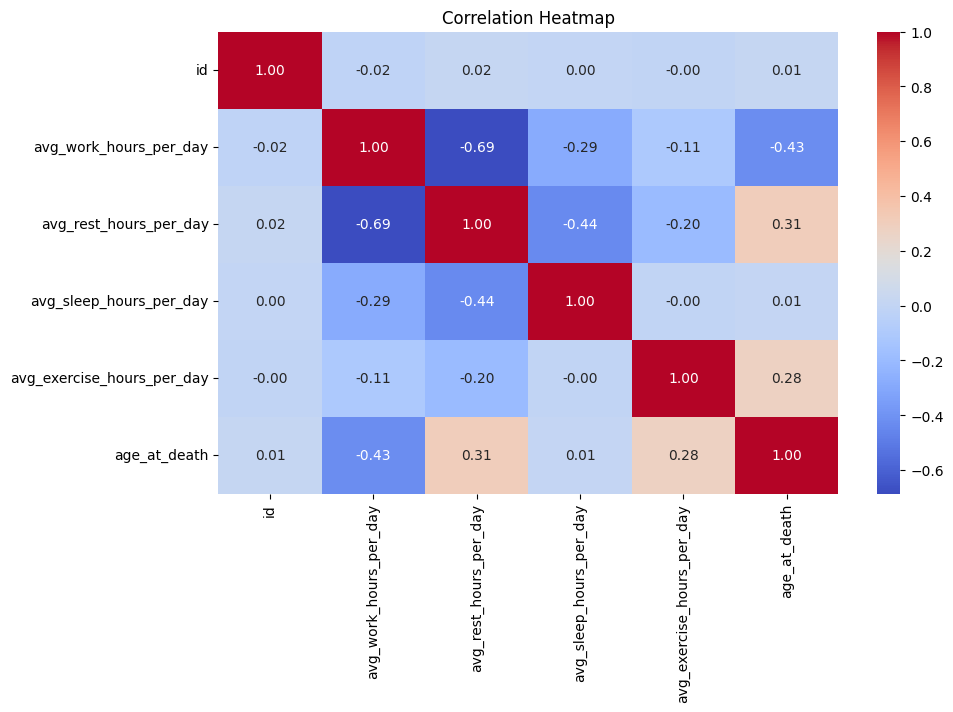

In [7]:
corr = df.select_dtypes(include = 'number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr,annot =True,cmap ='coolwarm',fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

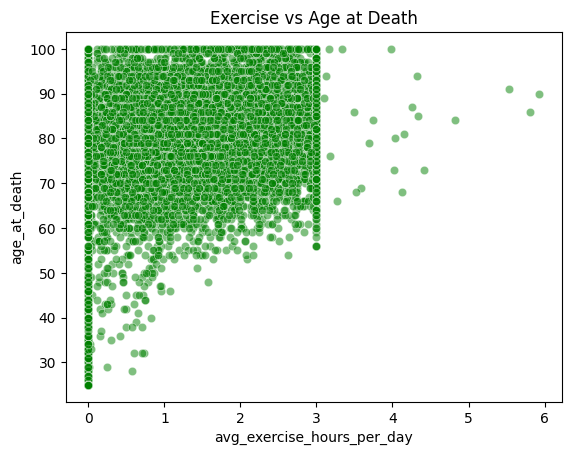

In [ ]:
sns.scatterplot(
    x = 'avg_exercise_hours_per_day',
    y = "age_at_death",
    data = df,
    alpha = 0.5,
    color = 'green'
)
plt.title("Exercise vs Age at Death")
plt.show()

/tmp/ipykernel_994/2885913132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


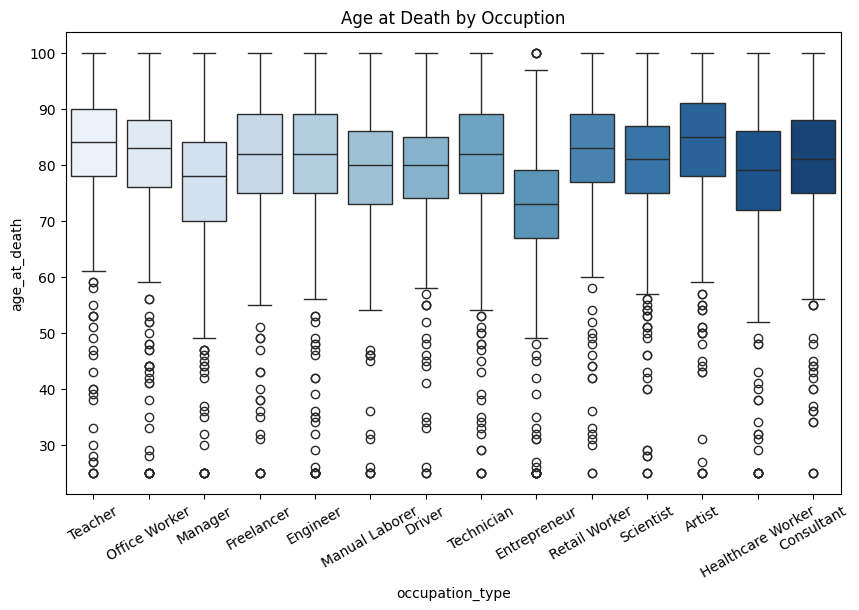

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x = "occupation_type",
    y = "age_at_death",
    data = df,
    palette = "Blues"
)
plt.xticks(rotation=30)
plt.title("Age at Death by Occuption")
plt.show()

In [ ]:
df["total_hours"] = (
    df["avg_work_hours_per_day"] +
    df["avg_rest_hours_per_day"] +
    df["avg_sleep_hours_per_day"] +
    df["avg_exercise_hours_per_day"]
)

df["total_hours"].describe()

,total_hours
count,10000.000000
mean,24.000357
std,0.013602
min,23.990000
25%,24.000000
50%,24.000000
75%,24.000000
max,24.650000


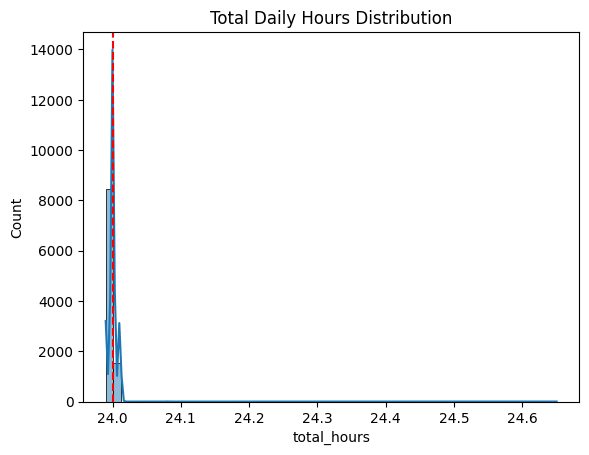

In [ ]:
sns.histplot(df['total_hours'],bins =  60,kde =True)
plt.axvline(24,color='red',linestyle='--')
plt.title("Total Daily Hours Distribution")
plt.show()

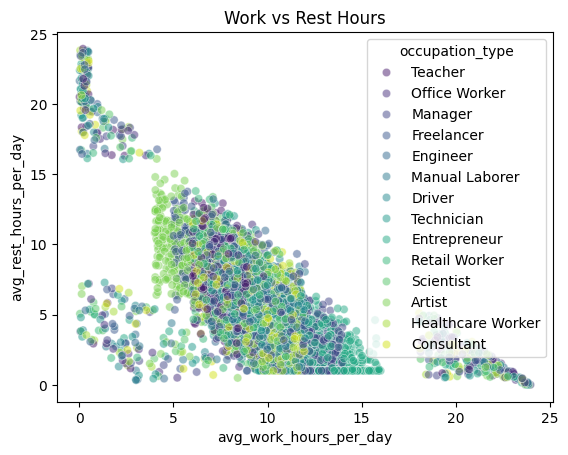

In [ ]:
sns.scatterplot(
    x = "avg_work_hours_per_day",
    y = "avg_rest_hours_per_day",
    data = df,
    alpha = 0.5,
    color = 'blue',
    palette = "viridis",
    hue = "occupation_type"
)
plt.title("Work vs Rest Hours")
plt.show()

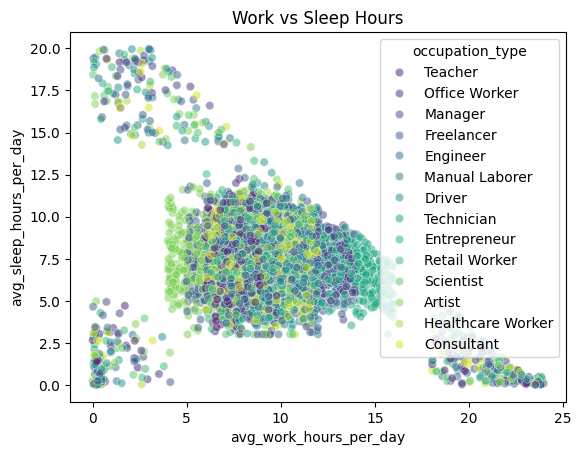

In [ ]:
sns.scatterplot(
    x = "avg_work_hours_per_day",
    y = "avg_sleep_hours_per_day",
    data = df,
    alpha = 0.5,
    color = 'green',
    palette = "viridis",
    hue = "occupation_type"
)
plt.title("Work vs Sleep Hours")
plt.show()

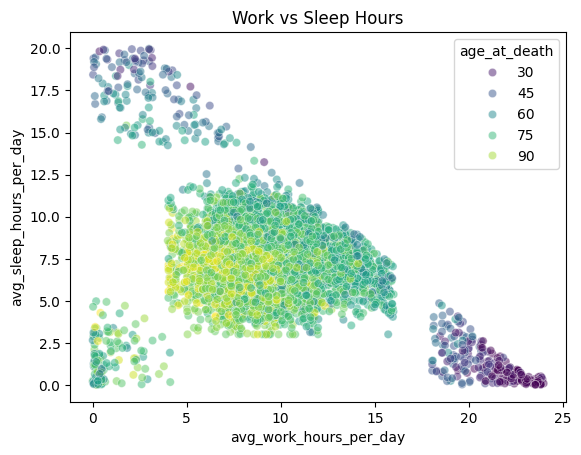

In [ ]:
sns.scatterplot(
    x = "avg_work_hours_per_day",
    y = "avg_sleep_hours_per_day",
    data = df,
    alpha = 0.5,
    color = 'green',
    palette = "viridis",
    hue = "age_at_death"
)
plt.title("Work vs Sleep Hours")
plt.show()

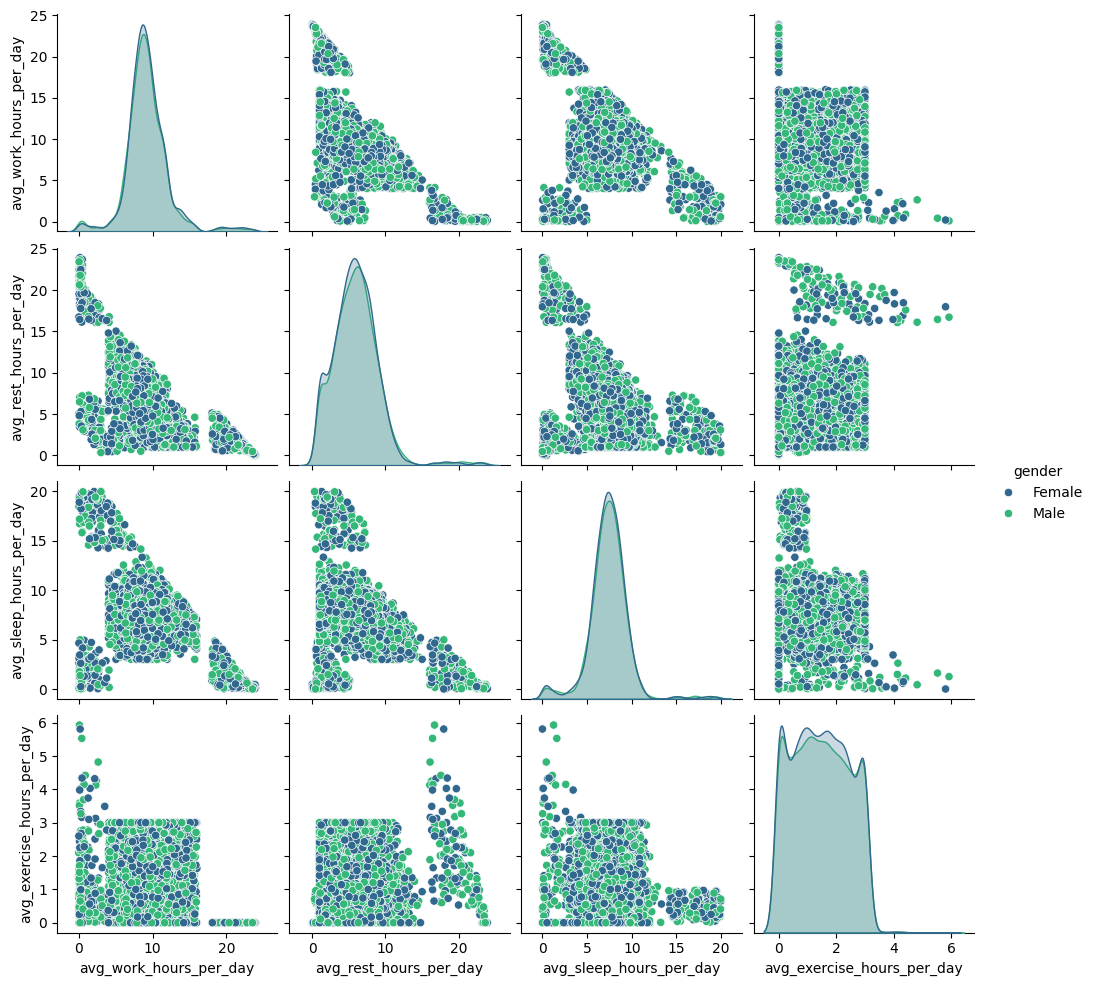

In [ ]:
sns.pairplot(
    df,
    vars = ["avg_work_hours_per_day","avg_rest_hours_per_day","avg_sleep_hours_per_day","avg_exercise_hours_per_day"],
    hue = "gender",
    palette = "viridis"
)
plt.show()

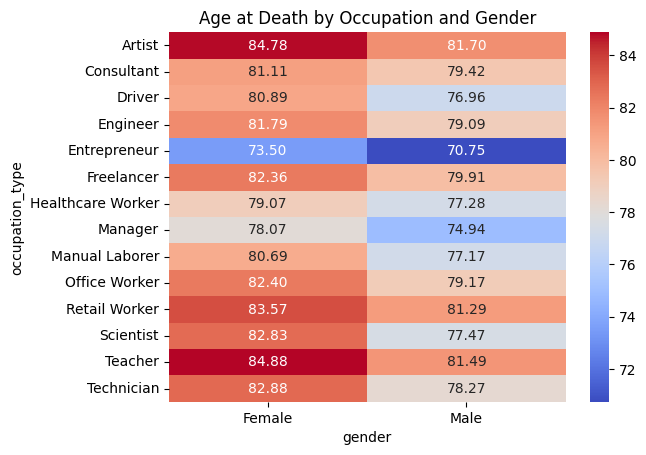

In [ ]:
pivot =df.pivot_table(
    values = "age_at_death",
    index = "occupation_type",
    columns = "gender",
    aggfunc = "mean"
)

sns.heatmap(pivot,annot =True,cmap ='coolwarm',fmt = ".2f")
plt.title("Age at Death by Occupation and Gender")
plt.show()

In [ ]:
optimal_sleep = 8
df["counterfactual_age"]=(
    df["age_at_death"]+
    (optimal_sleep-df["avg_sleep_hours_per_day"])* 1.2
)

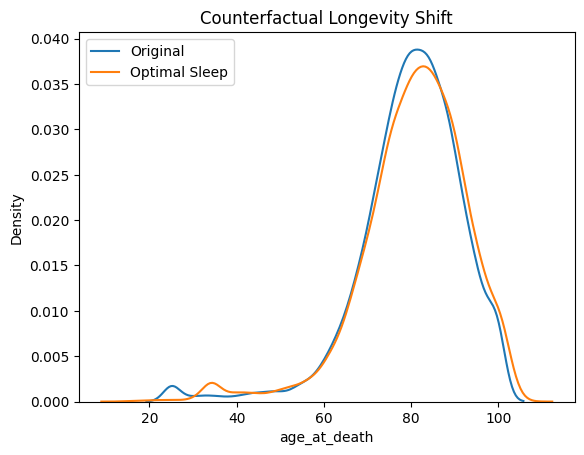

In [ ]:
sns.kdeplot(df['age_at_death'],label = "Original")
sns.kdeplot(df["counterfactual_age"],label = "Optimal Sleep")
plt.legend()
plt.title("Counterfactual Longevity Shift")
plt.show()

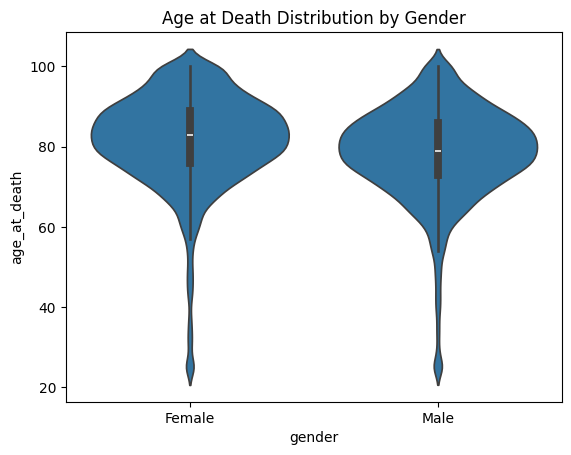

In [ ]:
sns.violinplot(
    x="gender",
    y="age_at_death",
    data=df
)
plt.title("Age at Death Distribution by Gender")
plt.show()

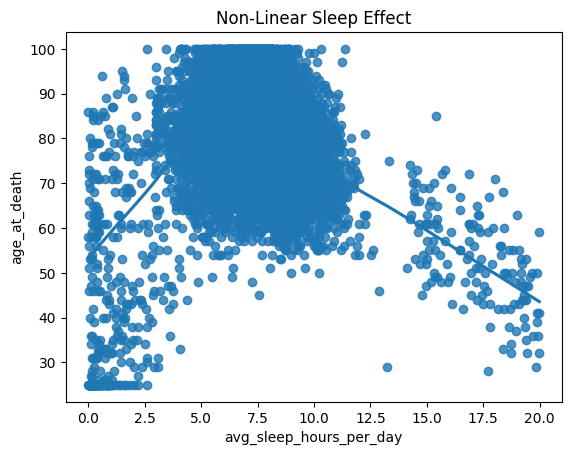

In [ ]:
sns.regplot(
    x="avg_sleep_hours_per_day",
    y="age_at_death",
    data=df,
    lowess=True
)
plt.title("Non-Linear Sleep Effect")
plt.show()

### One-hot encoding for categorical variables

In [8]:
df = pd.get_dummies(df, drop_first=True)

### Features & target

In [9]:
X = df.drop("age_at_death", axis=1)
y = df["age_at_death"]

### Train-test split

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Models

In [24]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

### Store results

In [31]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

### Metrics

In [33]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

results.append([
    name, train_r2, test_r2,
    train_rmse, test_rmse,
    train_mae, test_mae
])


### Results DataFrame

In [34]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Train R2", "Test R2",
    "Train RMSE", "Test RMSE",
    "Train MAE", "Test MAE"
])

print(results_df)


        Model  Train R2   Test R2  Train RMSE  Test RMSE  Train MAE  Test MAE
0  ElasticNet  0.270574  0.276471    10.24941  10.310352   7.663572  7.776547


### 📊 Visualization 1: R2 Comparison

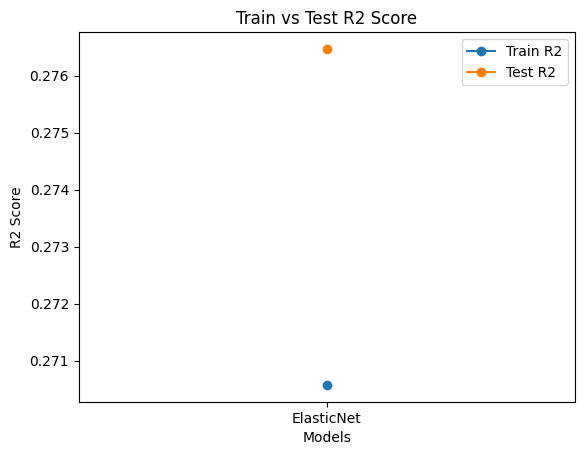

In [35]:
plt.figure()
plt.plot(results_df["Model"], results_df["Train R2"], marker='o', label="Train R2")
plt.plot(results_df["Model"], results_df["Test R2"], marker='o', label="Test R2")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Train vs Test R2 Score")
plt.legend()
plt.show()

### 📊 Visualization 2: RMSE Comparison

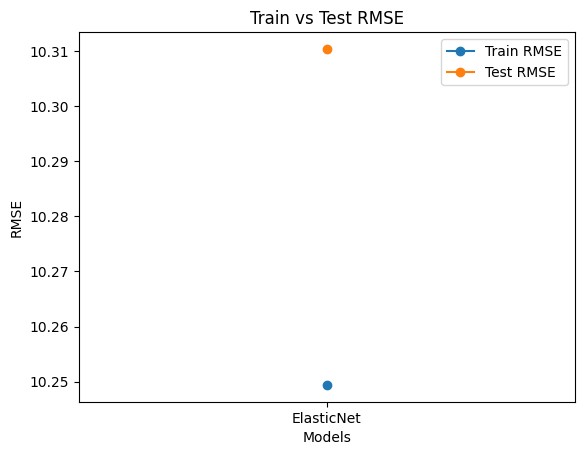

In [36]:

plt.figure()
plt.plot(results_df["Model"], results_df["Train RMSE"], marker='o', label="Train RMSE")
plt.plot(results_df["Model"], results_df["Test RMSE"], marker='o', label="Test RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Train vs Test RMSE")
plt.legend()
plt.show()

### 📊 Visualization 3: MAE Comparison

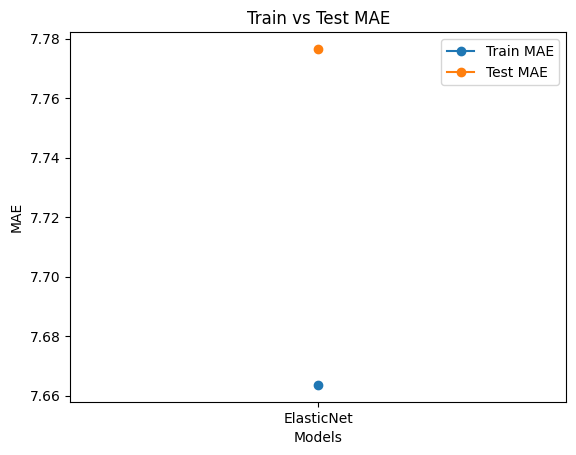

In [37]:
plt.figure()
plt.plot(results_df["Model"], results_df["Train MAE"], marker='o', label="Train MAE")
plt.plot(results_df["Model"], results_df["Test MAE"], marker='o', label="Test MAE")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Train vs Test MAE")
plt.legend()
plt.show()